In [1]:
import json
# from google import genai

def process_weather_data(geojson_path):
    """
    STEP 1 & 2: Deterministic Parsing
    Since your GeoJSON already has the province and location tags, 
    we just extract exactly what the LLM needs to know.
    """
    with open(geojson_path, 'r') as f:
        data = json.load(f)
        
    alert_summary = {}
    
    # Iterate through all the polygons in the GeoJSON
    for feature in data.get('features', []):
        props = feature.get('properties', {})
        location = props.get('location_name', 'Unknown Region')
        
        # Look at the active alerts for this polygon
        for alert in props.get('alerts', []):
            province = alert.get('Province', 'Unknown')
            # Clean up event name (e.g. "snowfall_warning" -> "Snowfall Warning")
            event_type = alert.get('event_type', 'Alert').replace('_', ' ').title()
            
            value = alert.get('value', 0)
            unit = alert.get('unit', '')
            
            if province not in alert_summary:
                alert_summary[province] = []
                
            # Create a clean string: "Snowfall Warning in Chibougamau: 16.4 cm"
            formatted_alert = f"{event_type} in {location}: {round(value, 1)} {unit}"
            alert_summary[province].append(formatted_alert)
            
    return alert_summary

In [2]:
geojson_path = "merged_events_email.json"
# with open(geojson_path, 'r') as f:
#     data = json.load(f)
# data.get('features', [])    

a = process_weather_data(geojson_path)

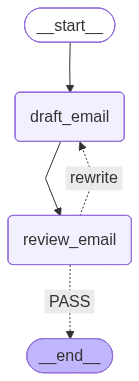

In [75]:
import os
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq
# from langchain_deepseek import ChatDeepSeek

load_dotenv()  # Load environment variables from .env file
# ==========================================
# PART 2: LANGGRAPH EMAIL GENERATOR
# ==========================================

# 1. Define the State
class EmailState(TypedDict):
    weather_summary: str
    email_draft: str
    review_feedback: str
    final_email: str
    revision_count: int

# Initialize the LLM (ensure GOOGLE_API_KEY is in your environment)
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
    # max_retries=5,       # Automatically retry up to 5 times on 503/429 errors
    # timeout=120          # Give the API enough time to process if it's slow
# llm = ChatGroq(model="llama-3.3-70b-versatile") 
# llm = ChatGroq(model="openai/gpt-oss-120b")
# llm = ChatDeepSeek(model="deepseek-reasoner", temperature=0)

# 2. Define the Nodes
def draft_email(state: EmailState):
    """Drafts the initial email or revises it based on feedback."""
    feedback = state.get("review_feedback", "")
    
    prompt = f"""
    You are the lead communicator for the weather alert team. 
    Write a concise, professional email starting with "Hi Team," summarizing these weather alerts:
    {state['weather_summary']}
    
    INSTRUCTIONS:
    1. Group alerts clearly by province.
    2. Synthesize regions logically (e.g., "northern and eastern regions").You MUST be meticulously accurate when determining these areas based on the provided locations. Verify the geography mentally before summarizing (e.g., do not label a region as "Central" if the specific locations are actually in "Northwestern" parts of the province).
      
    3. STRICT RULE: Do NOT include ANY specific city, town, or exact location names. Only refer to the broad regions.
    4.Include the specific max/mean values (e.g., "up to 96 km/h").
    5. SIGN-OFF: You must end the email exactly with: "Best regards,\nGeo Intelligence team"

    """
    # 3. BE CONCISE: Do NOT exhaustively list all the cities or regions. Summarize the broad area and only mention 1 or 2 key locations as examples for context.
        
    # 5. Organize the alerts by province. Each province must serve as a header on its own line. Underneath, group all corresponding alerts into a bulleted list. Each list item must start with the alert type in bold, followed by a colon and the description.

    #     Follow this structure exactly:
    #     [Province Name, not accronym]:            
    #         [Alert Type]: [Alert Details/Description]
    #         [Alert Type]: [Alert Details/Description]
    if feedback:
        prompt += f"\n\nREVISION REQUIRED BASED ON THIS FEEDBACK:\n{feedback}"
        
    response = llm.invoke([HumanMessage(content=prompt)])
    
    return {
        "email_draft": response.content, 
        "revision_count": state.get("revision_count", 0) + 1
    }

def review_email(state: EmailState):
    """Reviews the draft to ensure it meets strict formatting rules."""
    draft = state["email_draft"]
    original_data = state["weather_summary"]
    
    prompt = f"""
    Review this weather alert email draft against the original data.
    
    Original Data (containing specific locations):
    {original_data}
    
    Draft Email:
    {draft}
  
    
    Check for four critical things:
    1. GEOGRAPHICAL ACCURACY: Cross-reference the broad regions mentioned in the Draft against the specific locations in the Original Data. Did the drafter accurately describe the broad region? (e.g., If the original locations are in the Northwest, fail the draft if it incorrectly calls it Central or Eastern).
    2. Are regions grouped logically into broad geographic areas?
    3. STRICT RULE CHECK: Is the email completely free of specific city or exact location names? (It must ONLY use broad regional terms).
    4. Are the specific numerical severity values (cm, km/h) included for the events?
    
    
    If all are PERFECT, reply with only the word "PASS".
    If it fails, reply with a short, specific critique of what to fix.
    """
    
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"review_feedback": response.content}

# 3. Define Conditional Routing
def route_review(state: EmailState):
    """Decides if we are done or need to revise."""
    # If the reviewer passed it, or we've tried too many times (prevent infinite loops)
    if "PASS" in state["review_feedback"] or state["revision_count"] >= 3:
        return "PASS"
    return "rewrite"


# 4. Build the Graph
workflow = StateGraph(EmailState)
workflow.add_node("draft_email", draft_email)
workflow.add_node("review_email", review_email)

workflow.set_entry_point("draft_email")
workflow.add_edge("draft_email", "review_email")
workflow.add_conditional_edges("review_email", route_review,
                             {
                                "rewrite": "draft_email",
                                "PASS": END
                              })

# Compile the LangGraph app
email_generator_app = workflow.compile()
from IPython.display import display, Image
display(Image(email_generator_app.get_graph().draw_mermaid_png()))


In [76]:
# 1. Process JSON
structured_data = process_weather_data("merged_events_email.json")

# # Mock data based on your JSON example for testing
# structured_data = {
#     "QC": [
#         "Snowfall Warning in LG Quatre - Laforge and Fontanges: 19.1 cm",
#         "Wind Warning in LG Quatre - Laforge and Fontanges: 96.5 km/h",
#         "Snowfall Warning in Chibougamau: 16.4 cm"
#     ]
# }

# 2. Run LangGraph Generation
initial_state = {
    "weather_summary": json.dumps(structured_data, indent=2),
    "email_draft": "",
    "review_feedback": "",
    "final_email": "",
    "revision_count": 0
}

print("Generating email via LangGraph...\n")
final_state = email_generator_app.invoke(initial_state)

# 3. Output result
print("--- FINAL EMAIL ---")
print(final_state["email_draft"])

Generating email via LangGraph...

--- FINAL EMAIL ---
Hi Team,

Please find a summary of current weather alerts across various regions:

**Manitoba (MB):**
*   **Snowfall Warnings** are in effect for central, western, and northern Manitoba, including major lake regions, with accumulations up to 19.9 cm.
*   **Snowfall Advisories** are issued for southeastern Manitoba, including the southern Interlake and eastern lake regions, expecting up to 9.8 cm.
*   A **Freezing Rain Warning** is in place for a localized area in southwestern Manitoba, with 1.1 mm of freezing rain expected.

**Quebec (QC):**
*   **Snowfall Warnings** affect central and northern Quebec, with up to 19.1 cm of snow.
*   **Wind Warnings** are active for southern, eastern, and far northern Quebec, with gusts up to 107.9 km/h.
*   **Extreme Wind Warnings** are in effect for scattered areas across eastern and northern Quebec, with gusts up to 116.0 km/h.

**Ontario (ON):**
*   **Snowfall Warnings** cover Northern Ontario,

In [69]:
print(final_state["email_draft"][0]["text"])

Hi Team,

Please find the summary of current weather alerts across the country:

**Western and Central Regions (Manitoba, Saskatchewan, Alberta)**
Significant snowfall is impacting these provinces, with warnings in place across central and northern areas; accumulations are reaching up to 19.9 cm. Additionally, a freezing rain alert is active in the central region of Manitoba. High wind warnings are in effect for the southwestern areas of Alberta and Saskatchewan, with gusts reaching up to 101.5 km/h.

**Northern and Northwestern Regions (British Columbia, Yukon, Northwest Territories, Nunavut)**
Widespread snowfall advisories are in effect across the northern territories and northern British Columbia, with accumulations generally reaching up to 15.7 cm. 

**Central and Eastern Regions (Ontario, Quebec)**
Heavy snowfall is affecting central and northern Ontario, as well as northern and central Quebec, with localized accumulations peaking at 21.2 cm. Furthermore, severe wind events are i

In [71]:
print(final_state["email_draft"][0]["text"])

Hi Team,

Please find the summary of current weather alerts across Canada below:

**Manitoba**
Significant snowfall is expected, with totals reaching up to 19.9 cm in the southwestern and central regions. Additional snowfall advisories are in effect for the eastern and interlake areas, with accumulations up to 9.8 cm. A freezing rain warning is also active for the western region.

**Quebec**
Extreme wind warnings are in effect for the northern and coastal regions, with gusts reaching up to 116.0 km/h. Snowfall warnings are active for the northern and central areas, with accumulations up to 19.1 cm.

**Ontario**
Snowfall warnings are in effect for the northern and northwestern regions, with maximum accumulations of 21.2 cm. Advisories for smaller snow totals up to 9.7 cm are active in the western border regions. Wind warnings are in effect for specific central, southern, and northern lake-adjacent areas, with gusts reaching 100.2 km/h.

**Saskatchewan**
Snowfall warnings are active for 